# HSV Color Histogram Feature Extraction - Chinese Traffic Signs

Extracts a 960-dimensional Hue/Saturation histogram per image (masked to the sign's exact contour shape), using the same shared ROI preprocessing as `01_hog_features_chinese.ipynb` (`pipeline.preprocessing.get_roi`) and `pipeline.features.extract_hsv_features`. Both notebooks see identical ROI crops and drop exactly the same samples when no traffic-sign contour is found - previously HOG fell back to the whole image on a failed segmentation while HSV silently dropped the sample, which could misalign the two feature sets.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
from sklearn.model_selection import train_test_split

from pipeline import annotations, features, paths, preprocessing

In [2]:
import matplotlib.pyplot as plt

## Load annotations and build the train / test / held-out splits

Identical split logic to `01_hog_features_chinese.ipynb` - same `train_test_split` call, same `random_state=42`, so the two feature sets line up row-for-row.

In [3]:
annotations_df, image_lookup = annotations.load_annotations()
train_pool_df, held_out_df = annotations.split_held_out(annotations_df)

train_annotations, test_annotations = train_test_split(
    train_pool_df,
    test_size=0.20,
    random_state=42,
    stratify=train_pool_df["category"],
)

annotations.assert_no_leakage(
    train_annotations["file_name"],
    test_annotations["file_name"],
    held_out_df["file_name"],
)

train_dataset = annotations.ChineseTrafficSignDataset(train_annotations, image_lookup)
test_dataset = annotations.ChineseTrafficSignDataset(test_annotations, image_lookup)
held_out_dataset = annotations.ChineseTrafficSignDataset(held_out_df, image_lookup)

print("Training pool:", len(train_pool_df))
print("Train split:", len(train_dataset))
print("Test split:", len(test_dataset))
print("Held-out (assignment-1):", len(held_out_dataset))
print("Classes:", train_pool_df["category"].nunique())

Training pool: 5914
Train split: 4731
Test split: 1183
Held-out (assignment-1): 84
Classes: 58


## Preview: preprocessed ROI feeding into the HSV histogram

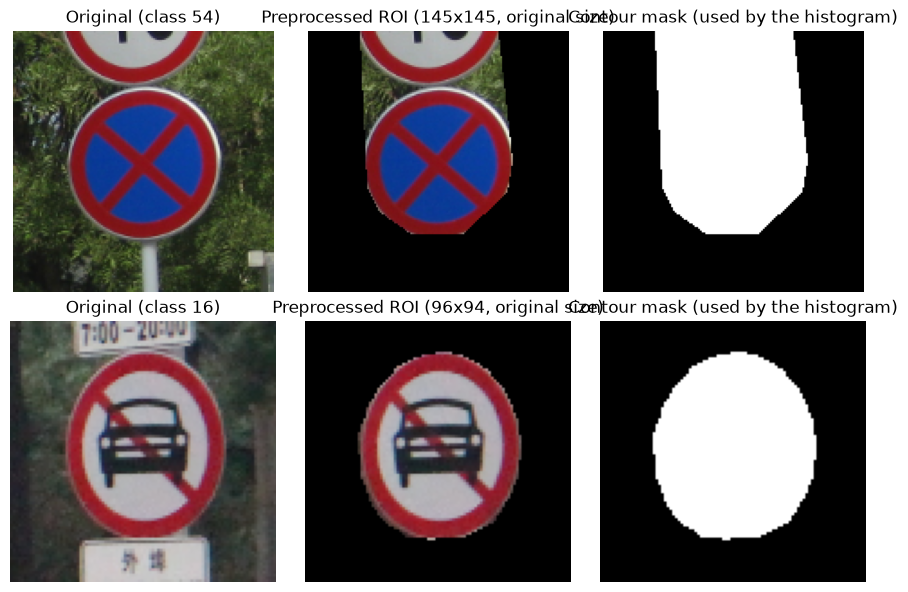

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

sample_indices = np.linspace(0, len(train_dataset) - 1, num=2, dtype=int).tolist()

for row, index in enumerate(sample_indices):
    image, label = train_dataset[index]
    roi = preprocessing.get_roi(np.array(image))

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Original (class {label})")

    if roi is None:
        axes[row, 1].text(0.5, 0.5, "No ROI", ha="center", va="center")
        axes[row, 2].axis("off")
    else:
        roi_rgb, roi_mask = roi
        axes[row, 1].imshow(roi_rgb)
        axes[row, 1].set_title(f"Preprocessed ROI ({roi_rgb.shape[1]}x{roi_rgb.shape[0]}, original size)")
        axes[row, 2].imshow(roi_mask, cmap="gray")
        axes[row, 2].set_title("Contour mask (used by the histogram)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## Extract features for each split

In [5]:
def extract_dataset(dataset, feature_fn):
    """Run pipeline.preprocessing.get_roi() + feature_fn over every image
    in dataset. Samples where no traffic-sign contour is found are dropped
    (see pipeline/preprocessing.py) - X/y/filenames stay aligned by row."""
    X, y, filenames, failed = [], [], [], []

    for index in range(len(dataset)):
        image, label = dataset[index]
        file_name = dataset.annotations.iloc[index]["file_name"]

        roi = preprocessing.get_roi(np.array(image))

        if roi is None:
            failed.append(file_name)
            continue

        roi_rgb, roi_mask = roi
        X.append(feature_fn(roi_rgb, roi_mask))
        y.append(label)
        filenames.append(file_name)

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    filenames = np.array(filenames)

    print(f"Extracted: {len(X)} / {len(dataset)} (failed: {len(failed)})")
    if failed:
        print("No contour detected for:", failed[:10], "..." if len(failed) > 10 else "")

    return X, y, filenames

In [6]:
hsv_feature_fn = lambda roi_rgb, roi_mask: features.extract_hsv_features(roi_rgb, roi_mask)

X_train, y_train, train_filenames = extract_dataset(train_dataset, hsv_feature_fn)
X_test, y_test, test_filenames = extract_dataset(test_dataset, hsv_feature_fn)
X_held_out, y_held_out, held_out_filenames_extracted = extract_dataset(
    held_out_dataset, hsv_feature_fn
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Held-out (assignment-1):", X_held_out.shape)

Extracted: 4719 / 4731 (failed: 12)
No contour detected for: ['014_0060.png', '054_0076.png', '031_1_0008_1_j.png', '038_1_0018_1_j.png', '016_1_0033_1_j.png', '014_1_0060.png', '014_0004.png', '027_1_0013_1_j.png', '014_1_0004.png', '031_0008_j.png'] ...


Extracted: 1177 / 1183 (failed: 6)
No contour detected for: ['027_0013_j.png', '013_0011_j.png', '054_1_0076.png', '013_1_0011_1_j.png', '016_0033_j.png', '031_1_0006_1_j.png'] 


Extracted: 84 / 84 (failed: 0)
Train: (4719, 960)
Test: (1177, 960)
Held-out (assignment-1): (84, 960)


## Save the feature files

In [7]:
paths.FEATURE_DIR.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    paths.FEATURE_DIR / "chinese_traffic_signs_hsv_features_train.npz",
    X=X_train, y=y_train, filenames=train_filenames,
)
np.savez_compressed(
    paths.FEATURE_DIR / "chinese_traffic_signs_hsv_features_test.npz",
    X=X_test, y=y_test, filenames=test_filenames,
)
np.savez_compressed(
    paths.FEATURE_DIR / "assignment1_test_hsv_features.npz",
    X=X_held_out, y=y_held_out, filenames=held_out_filenames_extracted,
)

print("Saved HSV feature files to:", paths.FEATURE_DIR.resolve())

Saved HSV feature files to: /home/hongye/projects/traffic-sign-recognition/features


## Task 1: HSV Recognition Rate Evaluation

Assignment 2 / Task 1 asks us to identify a feature extraction technique and evaluate its
**recognition rate** - not to train or score a classifier. This section evaluates the HSV
color histogram as a feature extraction technique on its own terms, over the same 84
Assignment-1 held-out images used above (`held_out_dataset`), using the assignment's
formula:

```
Recognition Rate = (Number of successfully extracted images / Total images) x 100%
```

No classifier (SVM, Random Forest, Decision Tree, etc.) and no classification metric
(accuracy, precision, recall, F1, confusion matrix) is used in this section - it uses the
same formula as the HOG Task 1 evaluation in `01_hog_features_chinese.ipynb`, applied to the
identical 84 images, so the two are directly comparable.

**Definition of "correctly extracted".** For every one of the 84 images, we run the HSV
extraction pipeline (`pipeline.preprocessing.get_roi` followed by
`pipeline.features.extract_hsv_features`) and call it a success only if **all** hold:

1. A traffic-sign contour is found, i.e. `get_roi` returns a ROI + mask instead of `None`.
2. `extract_hsv_features` runs on that ROI/mask without raising an exception.
3. The returned histogram vector is non-empty and has exactly the expected dimensionality
   for this bin configuration (derived below).
4. Every value in the vector is finite (no `NaN` / `Inf`).

Any image failing any of these four checks counts as a failed extraction.

In [8]:
import pandas as pd

### Expected HSV feature dimension

`extract_hsv_features` builds a 2D Hue/Saturation histogram with
`HSV_HUE_BINS x HSV_SATURATION_BINS` bins, flattened to a 1D vector:

```
feature_dim = HSV_HUE_BINS * HSV_SATURATION_BINS = 30 * 32 = 960
```

In [9]:
EXPECTED_HSV_DIM = features.HSV_HUE_BINS * features.HSV_SATURATION_BINS
print("Expected HSV feature dimension:", EXPECTED_HSV_DIM)

Expected HSV feature dimension: 960


### Run HSV extraction on all 84 images and score each one

`category` is recorded for reference in the saved report only - it is never used to judge
success, since Task 1 evaluates the extractor, not a classifier.

In [10]:
def evaluate_hsv_extraction(dataset, expected_dim):
    """Run the HSV extraction pipeline on every image in `dataset` and record a
    Task 1 success/failure verdict per image, keeping row order == dataset order."""
    records = []
    feature_vectors = []

    for index in range(len(dataset)):
        image, category = dataset[index]
        file_name = dataset.annotations.iloc[index]["file_name"]

        roi_found = False
        success = False
        reason = ""
        dim = 0
        vector = None

        try:
            roi = preprocessing.get_roi(np.array(image))
            if roi is None:
                reason = "No traffic-sign contour found (ROI extraction failed)"
            else:
                roi_found = True
                roi_rgb, roi_mask = roi
                vector = features.extract_hsv_features(roi_rgb, roi_mask)

                if vector is None or vector.size == 0:
                    reason = "Empty HSV histogram vector"
                elif vector.shape[0] != expected_dim:
                    reason = f"Unexpected HSV dimension: {vector.shape[0]} != {expected_dim}"
                elif not np.all(np.isfinite(vector)):
                    reason = "HSV histogram vector contains NaN/Inf"
                else:
                    success = True
                    dim = vector.shape[0]
        except Exception as exc:
            reason = f"Exception during extraction: {exc!r}"

        records.append({
            "index": index,
            "file_name": file_name,
            "category": category,
            "roi_found": roi_found,
            "success": success,
            "dim": dim,
            "reason": reason,
        })
        feature_vectors.append(vector if success else None)

    return pd.DataFrame.from_records(records), feature_vectors


hsv_task1_results, hsv_task1_vectors = evaluate_hsv_extraction(held_out_dataset, EXPECTED_HSV_DIM)
hsv_task1_results.head()

,index,file_name,category,roi_found,success,dim,reason
0,0,001_0004.png,1,True,True,960,
1,1,002_0036.png,2,True,True,960,
2,2,005_0030.png,5,True,True,960,
3,3,020_0003.png,20,True,True,960,
4,4,020_0004.png,20,True,True,960,


### Task 1 recognition rate report

In [11]:
hsv_task1_total = len(held_out_dataset)
hsv_task1_success = int(hsv_task1_results["success"].sum())
hsv_task1_failed = hsv_task1_total - hsv_task1_success
hsv_task1_rate = hsv_task1_success / hsv_task1_total * 100

print("Total images:                ", hsv_task1_total)
print("Successfully extracted:      ", hsv_task1_success)
print("Failed images:                ", hsv_task1_failed)
print(f"Recognition rate:              {hsv_task1_rate:.2f}%")
print("HSV feature vector dimension:", EXPECTED_HSV_DIM)

if hsv_task1_failed:
    print()
    print("Failed images:")
    print(hsv_task1_results.loc[~hsv_task1_results["success"], ["file_name", "reason"]].to_string(index=False))

Total images:                 84
Successfully extracted:       84
Failed images:                 0
Recognition rate:              100.00%
HSV feature vector dimension: 960


### Visualize HSV extraction on example images

At least 10 examples, each showing the original image, the preprocessed ROI, and its
extracted Hue/Saturation histogram (the actual extracted feature, reshaped back to 2D and
shown as a heatmap) - the histogram is computed straight from the saved feature vectors
above, with no separate visualization-only call.

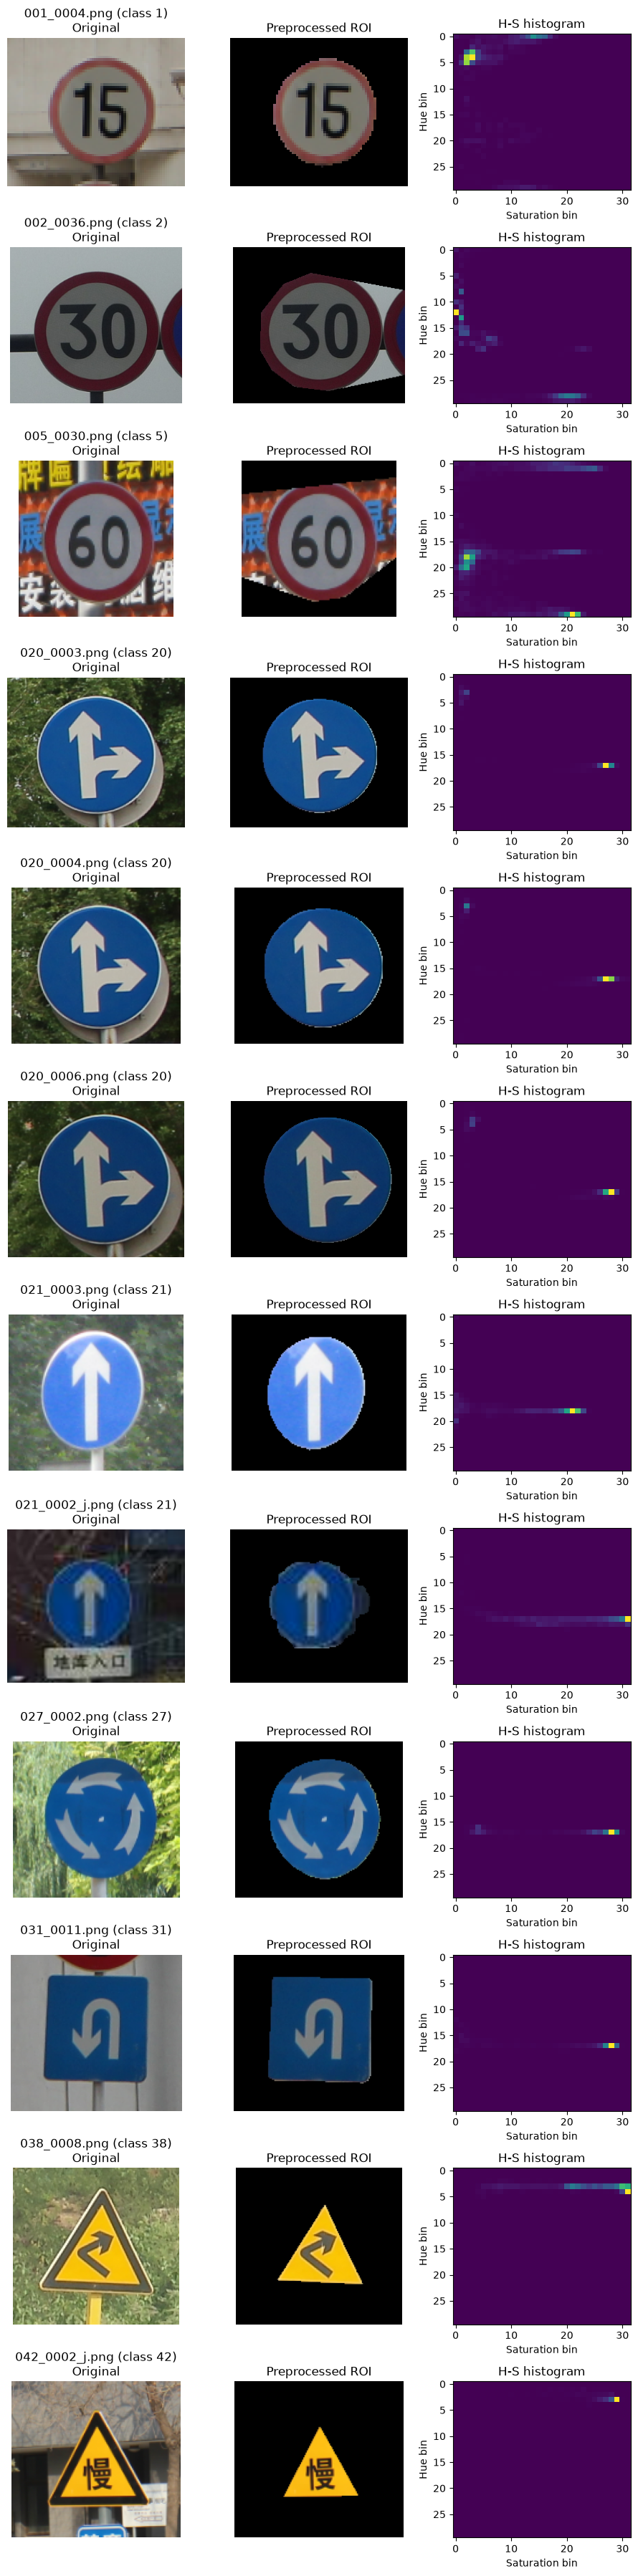

In [12]:
N_EXAMPLES = 12
hsv_example_indices = hsv_task1_results.loc[hsv_task1_results["success"]].index[:N_EXAMPLES].tolist()

fig, axes = plt.subplots(len(hsv_example_indices), 3, figsize=(9, 3 * len(hsv_example_indices)))

for row, index in enumerate(hsv_example_indices):
    image, category = held_out_dataset[index]
    file_name = hsv_task1_results.loc[index, "file_name"]

    roi_rgb, _roi_mask = preprocessing.get_roi(np.array(image))
    hist_2d = hsv_task1_vectors[index].reshape(features.HSV_HUE_BINS, features.HSV_SATURATION_BINS)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{file_name} (class {category})\nOriginal")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(roi_rgb)
    axes[row, 1].set_title("Preprocessed ROI")
    axes[row, 1].axis("off")

    im = axes[row, 2].imshow(hist_2d, aspect="auto", cmap="viridis")
    axes[row, 2].set_title("H-S histogram")
    axes[row, 2].set_xlabel("Saturation bin")
    axes[row, 2].set_ylabel("Hue bin")

plt.tight_layout()
plt.show()

### Save the Task 1 evaluation results

One artifact, index-aligned to the 84 Assignment-1 images in `held_out_df` order:

- `results/hsv_task1_recognition_84.csv` - the per-image success/failure report, for
  side-by-side comparison with the HOG Task 1 report.

The feature vectors themselves are not saved again here - `assignment1_test_hsv_features.npz`
(saved earlier, in "Save the feature files") already holds the successfully-extracted
vectors for these same 84 images, for downstream classifier use. Keeping a single feature
file per split avoids two independent extraction passes over the same images silently
drifting apart.

In [13]:
paths.RESULT_DIR.mkdir(parents=True, exist_ok=True)

hsv_task1_results.to_csv(paths.RESULT_DIR / "hsv_task1_recognition_84.csv", index=False)

print("Saved:", paths.RESULT_DIR / "hsv_task1_recognition_84.csv")

Saved: ../results/hsv_task1_recognition_84.csv


### Conclusion

Using the assignment's Task 1 formula - `Recognition Rate = (successfully extracted images /
total images) x 100%` - applied to the same 84 Assignment-1 images the HOG Task 1 evaluation
uses:

- **Total images:** 84
- **Successfully extracted / Failed / Recognition rate:** see the report printed above
- **HSV feature vector dimension:** 960

This HSV Task 1 recognition rate is directly comparable with the HOG Task 1 recognition rate
computed the same way in `01_hog_features_chinese.ipynb` - independent of, and not to be
confused with, either descriptor's downstream classification accuracy.